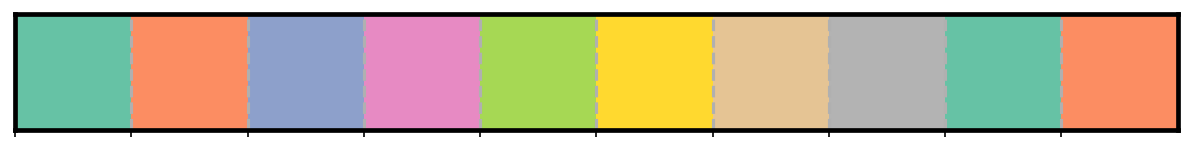

In [1]:
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import xarray as xr
import seaborn as sns
from scipy import stats
import cmocean
import pandas as pd
import cartopy.crs as ccrs
import warnings
import pickle
warnings.filterwarnings("ignore")
from tqdm import tqdm

def setup_plotting(ticksize=14, fontsize=20, figsize=(16, 9), dpi=150):
    """
    Global plotting setup with grey background and custom styling
    """

    # --- Figure defaults ---
    plt.rcParams.update({
        "figure.figsize": figsize,
        "figure.dpi": dpi,
    })

    # --- Background color ---
    plt.rcParams['axes.facecolor'] = "#e8e8e8"

    # --- Fonts ---
    rc = {"font.family": "serif", 
          "mathtext.fontset": "stix",
          "font.serif": ["DejaVu Serif"]}  # Better subscript support
    plt.rcParams.update(rc)
    
    plt.rcParams.update({
        "font.size": fontsize,
        "xtick.labelsize": ticksize,
        "ytick.labelsize": ticksize,
    })

    # --- Axes & ticks ---
    plt.rcParams.update({
        "axes.linewidth": 2.25,
        "axes.formatter.limits": (-1, 3),
        "axes.grid": True,
        "legend.facecolor": "white",
    })

    # --- Grid ---
    plt.rcParams.update({
        "grid.linestyle": "--",
        "grid.linewidth": 1.5,
    })

    # --- Color palette ---
    colors = sns.color_palette("Set2", 10)
    sns.set_palette(colors)
    sns.palplot(colors)
    plt.show()

    return colors




def stylize_ticks(fig, ax):
    """
    Apply inward ticks, minor ticks, and label offsets
    """

    ax.xaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, top=True)
    ax.yaxis.set_tick_params(which="major", direction="in",
                             width=2.5, length=12, right=True)

    ax.xaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, top=True)
    ax.yaxis.set_tick_params(which="minor", direction="in",
                             width=1.5, length=6, right=True)

    # Label offsets
    dx = -3 / 72
    dy = -3 / 72
    x_offset = matplotlib.transforms.ScaledTranslation(dx, 0, fig.dpi_scale_trans)
    y_offset = matplotlib.transforms.ScaledTranslation(0, dy, fig.dpi_scale_trans)

    for label in ax.xaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + y_offset)

    for label in ax.yaxis.get_majorticklabels():
        label.set_transform(label.get_transform() + x_offset)
colors = setup_plotting(ticksize=14, fontsize=20, figsize=(16, 9), dpi=150)

In [2]:
from Tracking_Functions import moaap

In [3]:
path = "/Users/asgerthormann/Documents/uni/master/master_code/data/pressure_levels_1h/5_days_1h_dec1999.nc"

ds = xr.open_dataset(path)
ds

<xarray.Dataset> Size: 11MB
Dimensions:         (valid_time: 120, pressure_level: 1, latitude: 121,
                     longitude: 181)
Coordinates:
  * valid_time      (valid_time) datetime64[ns] 960B 1999-12-01 ... 1999-12-0...
    expver          (valid_time) <U4 2kB ...
  * pressure_level  (pressure_level) float64 8B 500.0
  * latitude        (latitude) float64 968B 75.0 74.75 74.5 ... 45.5 45.25 45.0
  * longitude       (longitude) float64 1kB -20.0 -19.75 -19.5 ... 24.75 25.0
    number          int64 8B ...
Data variables:
    z               (valid_time, pressure_level, latitude, longitude) float32 11MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-09-08T09:45 GRIB to CDM+CF via cfgrib-0.9.1...

In [4]:
dT = 1 # time interval of input files [hours]
Mask = np.copy(ds['longitude']); Mask[:]=1 # tracking is applied globally
DataName = 'ERA5'
OutputFolder = 'moaap_output/'

time_datetime = pd.to_datetime(np.array(ds['valid_time'].values, dtype='datetime64'))


In [5]:
lon_1d = ds['longitude'].values
lat_1d = ds['latitude'].values

Lon, Lat = np.meshgrid(lon_1d, lat_1d)   # both now shape (n_lat, n_lon)
z500_data = np.array(ds['z'].sel(pressure_level=500)) # in m^2/s^2 conversion is done internally


In [6]:
object_split = moaap(
  Lon,
  Lat,
  time_datetime,
  dT,
  Mask,
  z500=z500_data,
  DataName=DataName,
  OutputFolder=OutputFolder,
  js_min_anomaly=12,
  MinTimeJS=12,
)

            latitude does not expand into the tropics
 
The provided variables allow tracking the following phenomena
 
|  phenomenon  | tracking |
---------------------------
   Jetstream   |   no
   PSL CY/ACY  |   no
   Z500 CY/ACY |   yes
   COLs        |   no
   IVT ARs     |   no
   MS ARs      |   no
   Fronts      |   no
   TCs         |   no
   MCSs        |   no
   Equ. Waves  |   no
---------------------------
 
======> track cyclones from Z500
    track 500 hPa cyclones
            3 object found
        break up long living cyclones using the breakup method


100%|██████████| 1/1 [00:00<00:00, 18.60it/s]


        00:00:00.11
    track 500 hPa anticyclones
            1 object found
        break up long living CY objects that heve many elements


100%|██████████| 1/1 [00:00<00:00, 175.44it/s]


        00:00:00.03
            Loop over 3 objects
            Loop over 1 objects
        00:00:00.26
 
Save the object masks into a joint netCDF
Saved: moaap_output/199912_ERA5_ObjectMasks__dt-1h_MOAAP-masks.nc
        00:00:00.18


In [7]:
data_moaap = xr.open_dataset('moaap_output/199912_ERA5_ObjectMasks__dt-1h_MOAAP-masks.nc')
data_moaap

<xarray.Dataset> Size: 32MB
Dimensions:           (time: 120, yc: 121, xc: 181)
Coordinates:
  * time              (time) datetime64[ns] 960B 1999-12-01 ... 1999-12-05T23...
    lat               (yc, xc) float32 88kB ...
    lon               (yc, xc) float32 88kB ...
Dimensions without coordinates: yc, xc
Data variables:
    CY_z500_Objects   (time, yc, xc) float32 11MB ...
    ACY_z500_Objects  (time, yc, xc) float32 11MB ...
    Z500              (time, yc, xc) float32 11MB ...
Attributes:
    title:    MOAAP object tracking output
    contact:  Andreas F. Prein (prein@ucar.edu)

In [8]:
with open('moaap_output/CY-z500_199912__dt-1h_MOAAP-masks.pkl', 'rb') as f:
    CY_charac = pickle.load(f)


In [9]:
display(data_moaap['CY_z500_Objects'])

<xarray.DataArray 'CY_z500_Objects' (time: 120, yc: 121, xc: 181)> Size: 11MB
[2628120 values with dtype=float32]
Coordinates:
  * time     (time) datetime64[ns] 960B 1999-12-01 ... 1999-12-05T23:00:00
    lat      (yc, xc) float32 88kB ...
    lon      (yc, xc) float32 88kB ...
Dimensions without coordinates: yc, xc
Attributes:
    longname:  cyclone objects according to Z500
    unit:

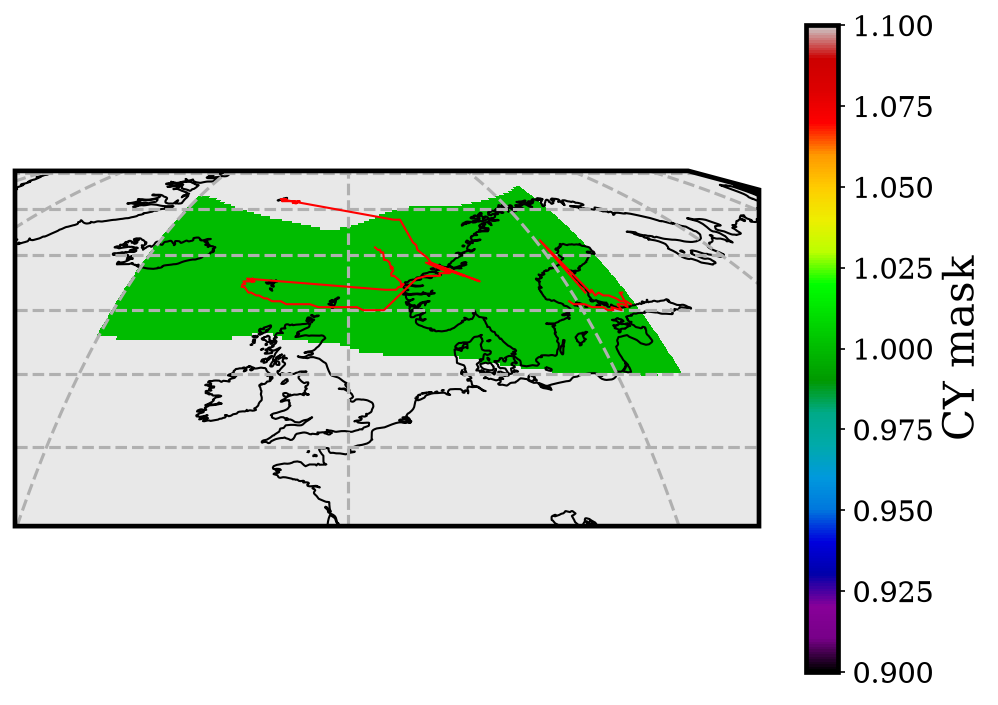

In [ ]:
# Create a figure and axis with a PlateCarree projection (latitude and longitude)
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()},
                       figsize=(8,8))

# Set the extent of the map (in this case, the entire globe)
#ax.set_extent([np.min(lat_1d), np.max(lat_1d), np.min(lon_1d), np.max(lon_1d)], crs=ccrs.PlateCarree())

# Add coastlines and gridlines for reference
ax.coastlines()
ax.gridlines()


# Generate some random data (latitude, longitude, and values)
CY_mask = np.array(data_moaap['CY_z500_Objects'][15,:,:])
CY_mask[CY_mask == 0] = np.nan
sc = plt.pcolormesh(data_moaap['lon'],
                    data_moaap['lat'],
                    CY_mask,
                    transform=ccrs.PlateCarree(),
                    cmap = 'nipy_spectral')


# plot CY tracks
for ii in range(len(CY_charac.keys())):
  LatLonTrack = CY_charac[list(CY_charac.keys())[ii]]['track']
  plt.plot(LatLonTrack[:,1],LatLonTrack[:,0], transform=ccrs.PlateCarree(), lw=1, color='r')

#ax.set_extent([np.min(lat_1d), np.max(lat_1d), np.min(lon_1d), np.max(lon_1d)], crs=ccrs.PlateCarree())

# Add a colorbar to the plot
cbar = plt.colorbar(sc, ax=ax, orientation='vertical', shrink=0.7, label='CY mask')

# Set the title of the plot
#plt.title('Cyclone tracks (red lines) and masks at '+str(time_datetime[12])[:16])

# Show the plot
plt.show()

In [11]:
CY_vals = data_moaap['CY_z500_Objects'].values

#check if all are NaN:
all_nan = np.all(np.isnan(CY_vals))
print(f"All values are NaN: {all_nan}")
# first non NaN value along the time dimension
first_non_nan_index = np.where(~np.isnan(CY_vals))[0][0]
print(f"Index of first non-NaN value: {first_non_nan_index}")


All values are NaN: False
Index of first non-NaN value: 0


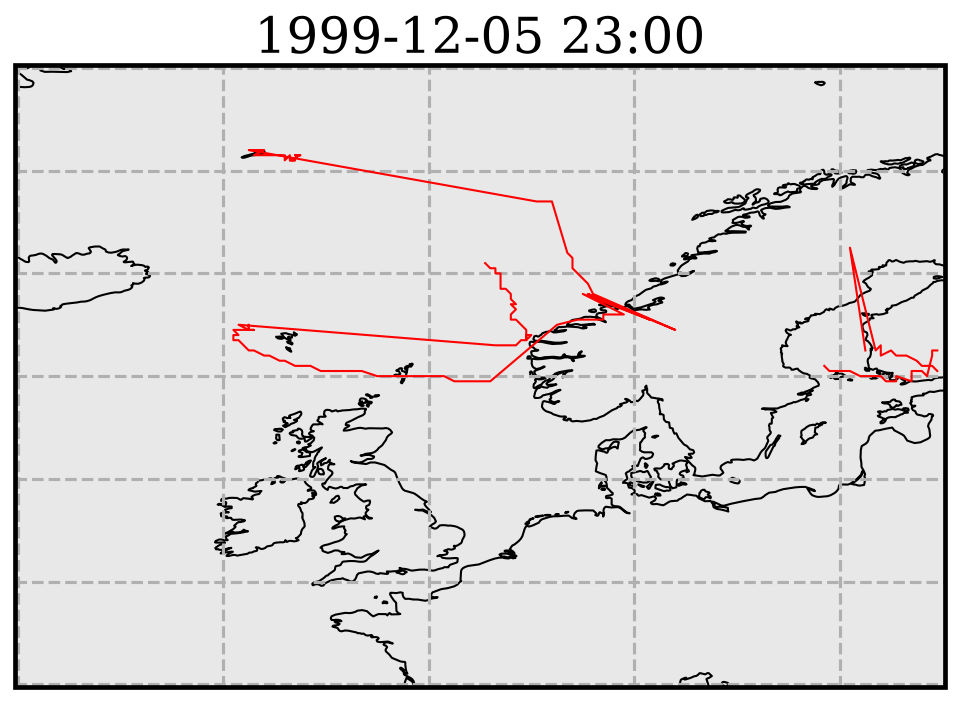

In [15]:
import matplotlib.animation as animation

object_data = data_moaap["CY_z500_Objects"].values
all_ids = np.asarray(object_data)

vmin = 1
vmax = np.nanmax(all_ids)
n_frames = object_data.shape[0]

longitude = data_moaap["lon"].values
latitude = data_moaap["lat"].values

fig, ax = plt.subplots(
    subplot_kw={
        "projection": ccrs.PlateCarree()
    },
    figsize=(8, 8),
)

ax.coastlines()
ax.gridlines()

mask = object_data[0].astype(float)
mask[mask == 0] = np.nan

mesh = ax.pcolormesh(
    longitude,
    latitude,
    mask,
    transform=ccrs.PlateCarree(),
    cmap="nipy_spectral",
    vmin=vmin,
    vmax=vmax,
)

for cyclone in CY_charac.values():
    track = cyclone["track"]
    ax.plot(
        track[:, 1],
        track[:, 0],
        transform=ccrs.PlateCarree(),
        linewidth=1,
        color="red",
    )

title = ax.set_title(str(time_datetime[0])[:16])


def update(frame):
    mask = object_data[frame].astype(float)
    mask[mask == 0] = np.nan

    mesh.set_array(mask.ravel())
    title.set_text(str(time_datetime[frame])[:16])

    return mesh, title


ani = animation.FuncAnimation(
    fig,
    update,
    frames=n_frames,
    interval=200,
    blit=False,
)

ani.save(
    "moaap_output/cyclone_animation.gif",
    writer="pillow",
    fps=2,
)

plt.show()